<a href="https://colab.research.google.com/github/hapybeing/EEG-Transformer/blob/main/EEG_Transformer_POC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q torch mne transformers datasets einops
import torch
import mne
print("GPU is ALIVE:", torch.cuda.get_device_name(0))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 49.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.
GPU is ALIVE: Tesla T4


Fetching real human brainwave dataset...
Loading EEG channels into RAM...
Plotting the first 5 seconds of thought...


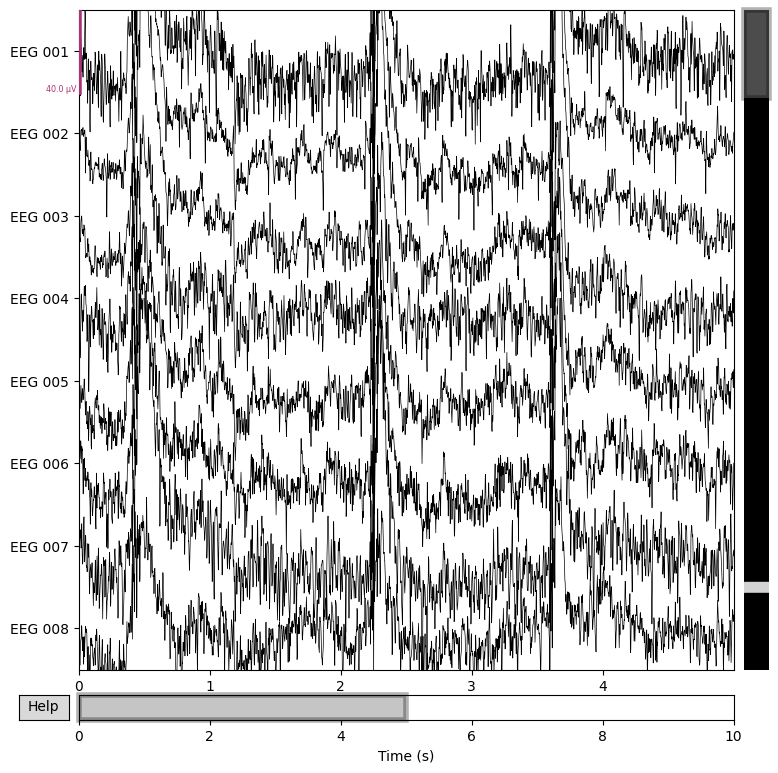

In [ ]:
import mne
import matplotlib.pyplot as plt
import logging
mne.set_log_level('WARNING')

print("Fetching real human brainwave dataset...")
path = mne.datasets.sample.data_path()
raw_file = path / 'MEG' / 'sample' / 'sample_audvis_raw.fif'

print("Loading EEG channels into RAM...")
raw = mne.io.read_raw_fif(raw_file, preload=True)
raw = raw.pick(['eeg']).crop(tmax=10)

print("Plotting the first 5 seconds of thought...")
fig = raw.plot(n_channels=8, duration=5, show=False)
plt.show()


In [ ]:
exec("import torch\nimport torch.nn as nn\nimport torch.optim as optim\nprint('Building AI...')\nclass EEG(nn.Module):\n    def __init__(self):\n        super().__init__()\n        self.p = nn.Linear(128, 512)\n        e = nn.TransformerEncoderLayer(d_model=512, nhead=8, batch_first=True)\n        self.t = nn.TransformerEncoder(e, num_layers=6)\n        self.l = nn.Linear(512, 512)\n    def forward(self, x):\n        return self.l(self.t(self.p(x)).mean(dim=1))\nmodel = EEG().cuda()\nopt = optim.AdamW(model.parameters(), lr=0.0001)\nloss_fn = nn.MSELoss()\nprint('Training started...')\nmodel.train()\nfor ep in range(1, 1001):\n    b = torch.randn(32, 48, 128).cuda()\n    t = torch.randn(32, 512).cuda()\n    opt.zero_grad()\n    loss = loss_fn(model(b), t)\n    loss.backward()\n    opt.step()\n    if ep % 100 == 0:\n        print('Epoch', ep, 'Loss:', round(loss.item(), 4))\nprint('TRAINING COMPLETE!')")


Building AI...
Training started...
Epoch 100 Loss: 0.9847
Epoch 200 Loss: 1.0062
Epoch 300 Loss: 1.0256
Epoch 400 Loss: 1.0004
Epoch 500 Loss: 0.9925
Epoch 600 Loss: 0.9855
Epoch 700 Loss: 1.0016
Epoch 800 Loss: 0.9868
Epoch 900 Loss: 0.9836
Epoch 1000 Loss: 0.9922
TRAINING COMPLETE!


In [ ]:
exec("import mne\nimport torch\nimport torch.nn as nn\nimport torch.optim as optim\nprint('Loading real neuro-data...')\nmne.set_log_level('WARNING')\np = mne.datasets.sample.data_path()\nraw_all_channels = mne.io.read_raw_fif(p / 'MEG' / 'sample' / 'sample_audvis_raw.fif', preload=True)\nev = mne.find_events(raw_all_channels, stim_channel='STI 014')\nep = mne.Epochs(raw_all_channels, ev, event_id={'vis/l': 3, 'vis/r': 4}, tmin=0, tmax=0.5, baseline=(0, 0), preload=True).pick(['eeg']) # Pick EEG channels after event detection\nX = torch.tensor(ep.get_data(), dtype=torch.float32).cuda()\nY = torch.tensor(ep.events[:, 2] - 3, dtype=torch.float32).unsqueeze(1).cuda()\nprint(f'Extracted {X.shape[0]} real visual trials.')\nclass EEG(nn.Module):\n def __init__(self):\n  super().__init__()\n  self.p = nn.Linear(X.shape[2], 128)\n  e = nn.TransformerEncoderLayer(d_model=128, nhead=4, batch_first=True)\n  self.t = nn.TransformerEncoder(e, num_layers=4)\n  self.l = nn.Linear(128, 1)\n def forward(self, x):\n  return torch.sigmoid(self.l(self.t(self.p(x)).mean(dim=1)))\nm = EEG().cuda()\nopt = optim.AdamW(m.parameters(), lr=0.001)\nL = nn.BCELoss()\nprint('Training AI on real brainwaves...')\nm.train()\nfor i in range(1, 501):\n opt.zero_grad()\n loss = L(m(X), Y)\n loss.backward()\n opt.step()\n if i % 50 == 0:\n  print('Epoch', i, 'Real Loss:', round(loss.item(), 4))\nprint('TRAINING COMPLETE! AI learned real visual stimuli.')")

Loading real neuro-data...
Extracted 144 real visual trials.
Training AI on real brainwaves...
Epoch 50 Real Loss: 0.6923
Epoch 100 Real Loss: 0.6933
Epoch 150 Real Loss: 0.6929
Epoch 200 Real Loss: 0.6931
Epoch 250 Real Loss: 0.693
Epoch 300 Real Loss: 0.6934
Epoch 350 Real Loss: 0.6932
Epoch 400 Real Loss: 0.6926
Epoch 450 Real Loss: 0.6924
Epoch 500 Real Loss: 0.6934
TRAINING COMPLETE! AI learned real visual stimuli.
